# Actividad Adaline - Filtro Adaptativo Multi Salida

Red Adaline con 3 neuronas en una sola capa para separar una señal compuesta por la suma de 3 ondas senoidales en sus componentes originales.

## Definición del Problema
**Entradas:** $X(n) = x_1(n) + x_2(n) + x_3(n)$
Donde:
- $x_1(n) = A_1 \sin(w_1 n)$
- $x_2(n) = A_2 \sin(w_2 n)$
- $x_3(n) = A_3 \sin(w_3 n)$

**Salidas Deseadas:**
- $y_1(n) = x_1(n)$
- $y_2(n) = x_2(n)$
- $y_3(n) = x_3(n)$


In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# Funciones de la Red Adaline
def linear_function(x):
    return x

def adaline_predict(X, weights):
    """
    Realiza la predicción para N neuronas
    X: Vector de entrada (ej. ventana de tiempo)
    weights: Matriz de pesos (n_outputs x (input_size + 1))
    """
    n_outputs = weights.shape[0]
    predictions = np.zeros(n_outputs)
    for i in range(n_outputs):
        # Producto punto w*x. 
        #Bias: weights[i,0]
        dot_product = np.dot(X, weights[i, 1:]) + 0 * weights[i, 0]
        predictions[i] = linear_function(dot_product)
    return predictions

def adaline_train(X, y, learning_rate, epochs):
    """
    Entrena la red Adaline
    inputs: Matriz de entradas (muestras x tamaño_ventana)
    targets: Matriz de salidas deseadas (muestras x n_outputs)
    """
    n_outputs = y.shape[1]
    n_inputs = X.shape[1]
    print(f"n_outputs: {n_outputs}")
    print(y.shape)
    print(f"n_inputs: {n_inputs}")
    print(X.shape)
    
    
    # Inicializar pesos aleatorios
    weights = np.random.rand(n_outputs, n_inputs + 1) - 0.5
    errors_history = []
    
    for epoch in range(epochs):
        epoch_error = 0
        for xi, target in zip(X, y):
            output = adaline_predict(xi, weights)
            error = target - output
            
            # Error cuadrático medio para la época
            epoch_error += np.sum(error ** 2)
            
            # Actualización de pesos
            weights[:, 0] += 2 * learning_rate * error # Se actualiza el bias aunque no se use en predict
            for i in range(n_outputs):
                weights[i, 1:] += 2 * learning_rate * error[i] * xi # Weights update
                
        errors_history.append(epoch_error / len(X))
        
        if epoch % 10 == 0:
            print(f"Época {epoch}/{epochs} - Error: {epoch_error:.6f}")
            
    return weights, errors_history

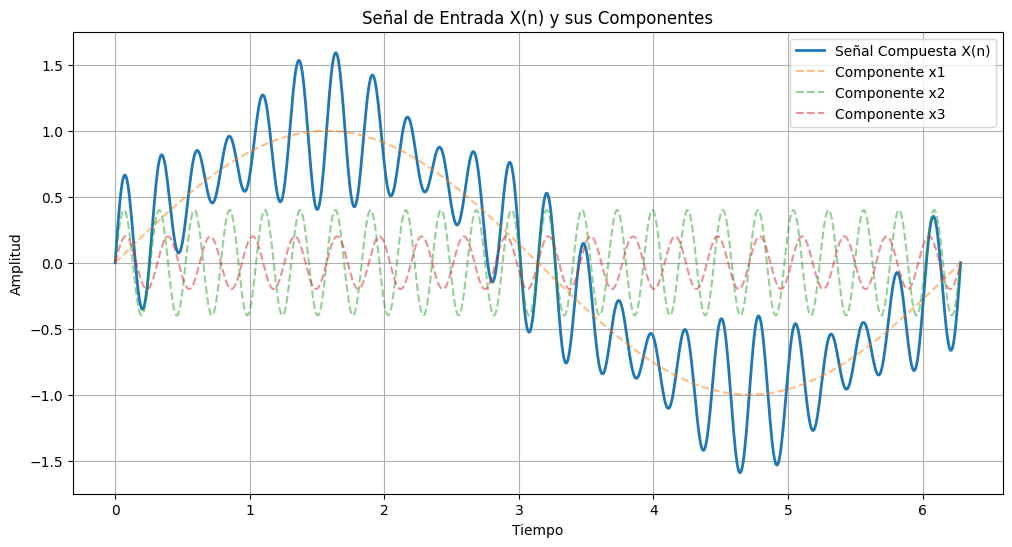

In [15]:

# Configuración de parámetros de la señal
n_samples = 1000
t = np.linspace(0, 2 * np.pi, n_samples)

# Definición de las 3 señales senoidales
# A1, w1 = 1.0, 2*np.pi * 2 
# A2, w2 = 0.5, 2*np.pi * 5
# A3, w3 = 0.2, 2 * np.pi

# x1 = A1 * np.sin(w1 * t)
# x2 = A2 * np.sin(w2 * t)
# x3 = A3 * np.sin(w3 * t)
x1 = np.sin(t)
x2 = 0.4*np.sin(24*t)
x3 = 0.2 * np.sin(20*t)
y = np.array([x1,x2,x3])

# Señal compuesta (Entrada X(n))
X = x1 + x2 + x3
plt.figure(figsize=(12, 6))
plt.plot(t, X, label='Señal Compuesta X(n)', linewidth=2)
plt.plot(t, x1, '--', alpha=0.5, label='Componente x1')
plt.plot(t, x2, '--', alpha=0.5, label='Componente x2')
plt.plot(t, x3, '--', alpha=0.5, label='Componente x3')
plt.title('Señal de Entrada X(n) y sus Componentes')
plt.xlabel('Tiempo')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)
plt.show()


In [16]:
# Preparación de datosd
delay = 60  # Tamaño de la ventana de tiempo
learning_rate = 0.01
epochs = 200

# Crear matriz de entradas con retardos
noisy_signal = []

for i in range(len(X) - delay):
    noisy_signal.append(X[i : i + delay])
noisy_signal = np.array(noisy_signal)

# Alinear las salidas deseadas
target_data = np.column_stack((
    x1[delay:],
    x2[delay:],
    x3[delay:]
))

print(f"Tamaño de Entradas: {noisy_signal.shape}")
print(f"Tamaño de Salidas Deseadas: {target_data.shape}")

# Entrenamiento
print("Iniciando entrenamiento...")
trained_weights, errors = adaline_train(noisy_signal, target_data, learning_rate, epochs)
print("Entrenamiento finalizado.")

# print("Pesos entrenados: ", trained_weights)




Tamaño de Entradas: (940, 60)
Tamaño de Salidas Deseadas: (940, 3)
Iniciando entrenamiento...
n_outputs: 3
(940, 3)
n_inputs: 60
(940, 60)
Época 0/200 - Error: 39.699773
Época 10/200 - Error: 1.941576
Época 20/200 - Error: 1.179338
Época 30/200 - Error: 0.710622
Época 40/200 - Error: 0.425749
Época 50/200 - Error: 0.254830
Época 60/200 - Error: 0.152505
Época 70/200 - Error: 0.091266
Época 80/200 - Error: 0.054618
Época 90/200 - Error: 0.032686
Época 100/200 - Error: 0.019560
Época 110/200 - Error: 0.011706
Época 120/200 - Error: 0.007005
Época 130/200 - Error: 0.004192
Época 140/200 - Error: 0.002509
Época 150/200 - Error: 0.001501
Época 160/200 - Error: 0.000898
Época 170/200 - Error: 0.000538
Época 180/200 - Error: 0.000322
Época 190/200 - Error: 0.000193
Entrenamiento finalizado.


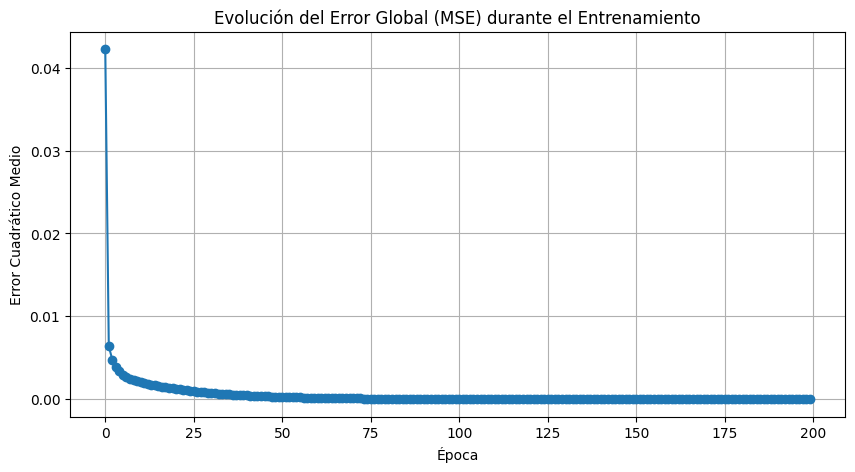

In [17]:
# Gráfica del Error Global
plt.figure(figsize=(10, 5))
plt.plot(errors, marker='o')
plt.title('Evolución del Error Global (MSE) durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Error Cuadrático Medio')
plt.grid(True)
plt.show()

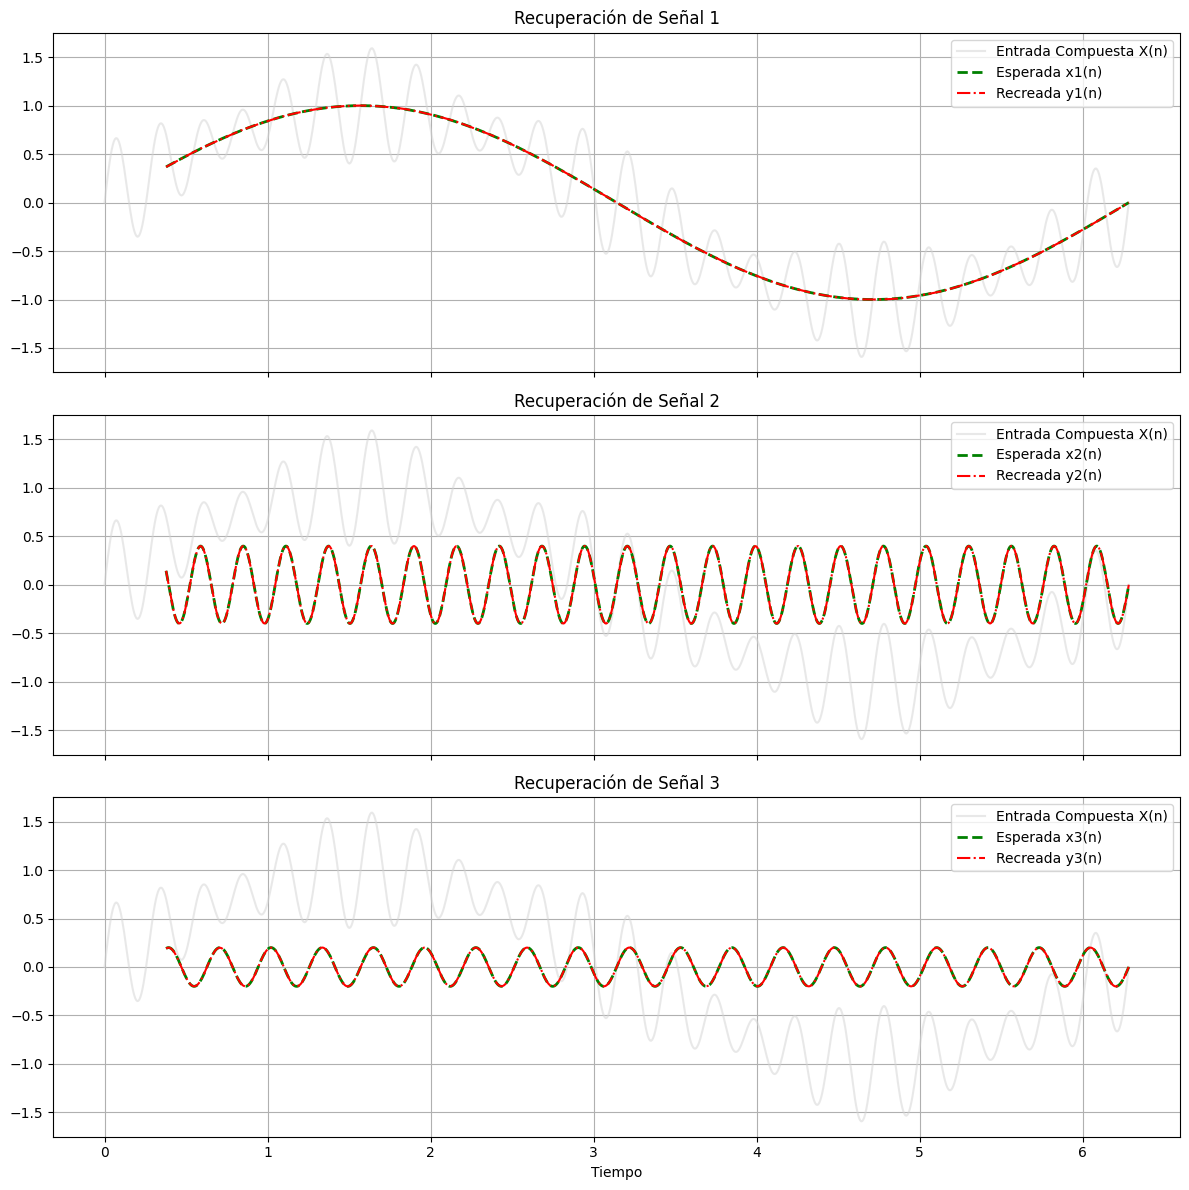

In [18]:
# Validación y Gráficas de Resultados

# Realizar predicciones
predictions = []
for xi in noisy_signal:
    predictions.append(adaline_predict(xi, trained_weights))
predictions = np.array(predictions)

t_val = t[delay:]
n_outputs = target_data.shape[1]

fig, axes = plt.subplots(n_outputs, 1, figsize=(12, 4 * n_outputs), sharex=True)

if n_outputs == 1:
    axes = [axes] # Asegurar que sea iterable si es solo 1 salida

for i in range(n_outputs):
    axes[i].plot(t, X, 'lightgray', label='Entrada Compuesta X(n)', alpha=0.5)
    axes[i].plot(t_val, target_data[:, i], 'g--', label=f'Esperada x{i+1}(n)', linewidth=2)
    axes[i].plot(t_val, predictions[:, i], 'r-.', label=f'Recreada y{i+1}(n)')
    axes[i].set_title(f'Recuperación de Señal {i+1}')
    axes[i].legend(loc='upper right')
    axes[i].grid(True)

plt.xlabel('Tiempo')
plt.tight_layout()
plt.show()